# DATA CLEANING

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(
    "data_processed/final_combined/all_states_final_model_table.csv"
)

print("Initial shape:", df.shape)
df.head()



Initial shape: (16371, 21)


,GEOID,population,households,median_income,workers,mean_commute_time,vehicles_total,state,county,tract,...,station_count,total_ports,l2_ports,dcfc_ports,dist_nearest_charger_km,dist_nearest_dcfc_km,establishments_total,retail_establishments,food_establishments,service_establishments
0,6029004402,4667.0,1316.0,29515.0,1947.0,1723.0,1316.0,CA,29.0,4402.0,...,2,2,0,2,0.146392,0.146392,1.755024,0.364419,0.304055,0.201213
1,6047000802,4597.0,1532.0,77143.0,2354.0,1884.0,1532.0,CA,47.0,802.0,...,0,0,0,0,2.168054,2.168054,27.697959,4.743293,3.507162,3.032833
2,6085501402,2716.0,839.0,93092.0,1458.0,1222.0,839.0,CA,85.0,501402.0,...,0,0,0,0,0.441909,1.697251,182.507125,21.914341,20.509575,27.083878
3,6005000102,2338.0,960.0,69500.0,993.0,690.0,960.0,CA,5.0,102.0,...,0,0,0,0,20.483437,33.570788,93.986361,19.261036,31.957751,11.485438
4,6029004901,6074.0,1602.0,47167.0,2889.0,2439.0,1602.0,CA,29.0,4901.0,...,1,14,14,0,0.556859,0.882057,8.316997,1.667350,1.651546,1.003571


### Removing Invalid tracts [where population is zero]

In [3]:
df = df[df["population"] > 0].copy()

print("After removing zero population:", df.shape)


After removing zero population: (16206, 21)


### Checking Missiong Value

In [4]:
df.isna().mean().sort_values(ascending=False)


median_income              0.01265
GEOID                      0.00000
station_count              0.00000
food_establishments        0.00000
retail_establishments      0.00000
establishments_total       0.00000
dist_nearest_dcfc_km       0.00000
dist_nearest_charger_km    0.00000
dcfc_ports                 0.00000
l2_ports                   0.00000
total_ports                0.00000
state_code                 0.00000
population                 0.00000
tract                      0.00000
county                     0.00000
state                      0.00000
vehicles_total             0.00000
mean_commute_time          0.00000
workers                    0.00000
households                 0.00000
service_establishments     0.00000
dtype: float64

Here, we can only see the missing value for median_income column. Since, I have state so, I will impute missing median_income with state mediam value to preserve regional income structure.

In [5]:
df["median_income"] = df["median_income"].replace(0, np.nan)
df["median_income"] = (
    df.groupby("state")["median_income"]
      .transform(lambda x: x.fillna(x.median()))
)


In [6]:
df.groupby("state")["median_income"].median()


state
CA     94917.0
CO     90811.0
DC    111579.0
NY     83856.5
VT     77985.5
Name: median_income, dtype: float64

In [7]:
df["median_income"].isna().sum()


np.int64(0)

## Outlier

In [8]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numeric columns:")
print(numeric_cols)

Numeric columns:
Index(['GEOID', 'population', 'households', 'median_income', 'workers',
       'mean_commute_time', 'vehicles_total', 'county', 'tract',
       'station_count', 'total_ports', 'l2_ports', 'dcfc_ports',
       'dist_nearest_charger_km', 'dist_nearest_dcfc_km',
       'establishments_total', 'retail_establishments', 'food_establishments',
       'service_establishments'],
      dtype='str')


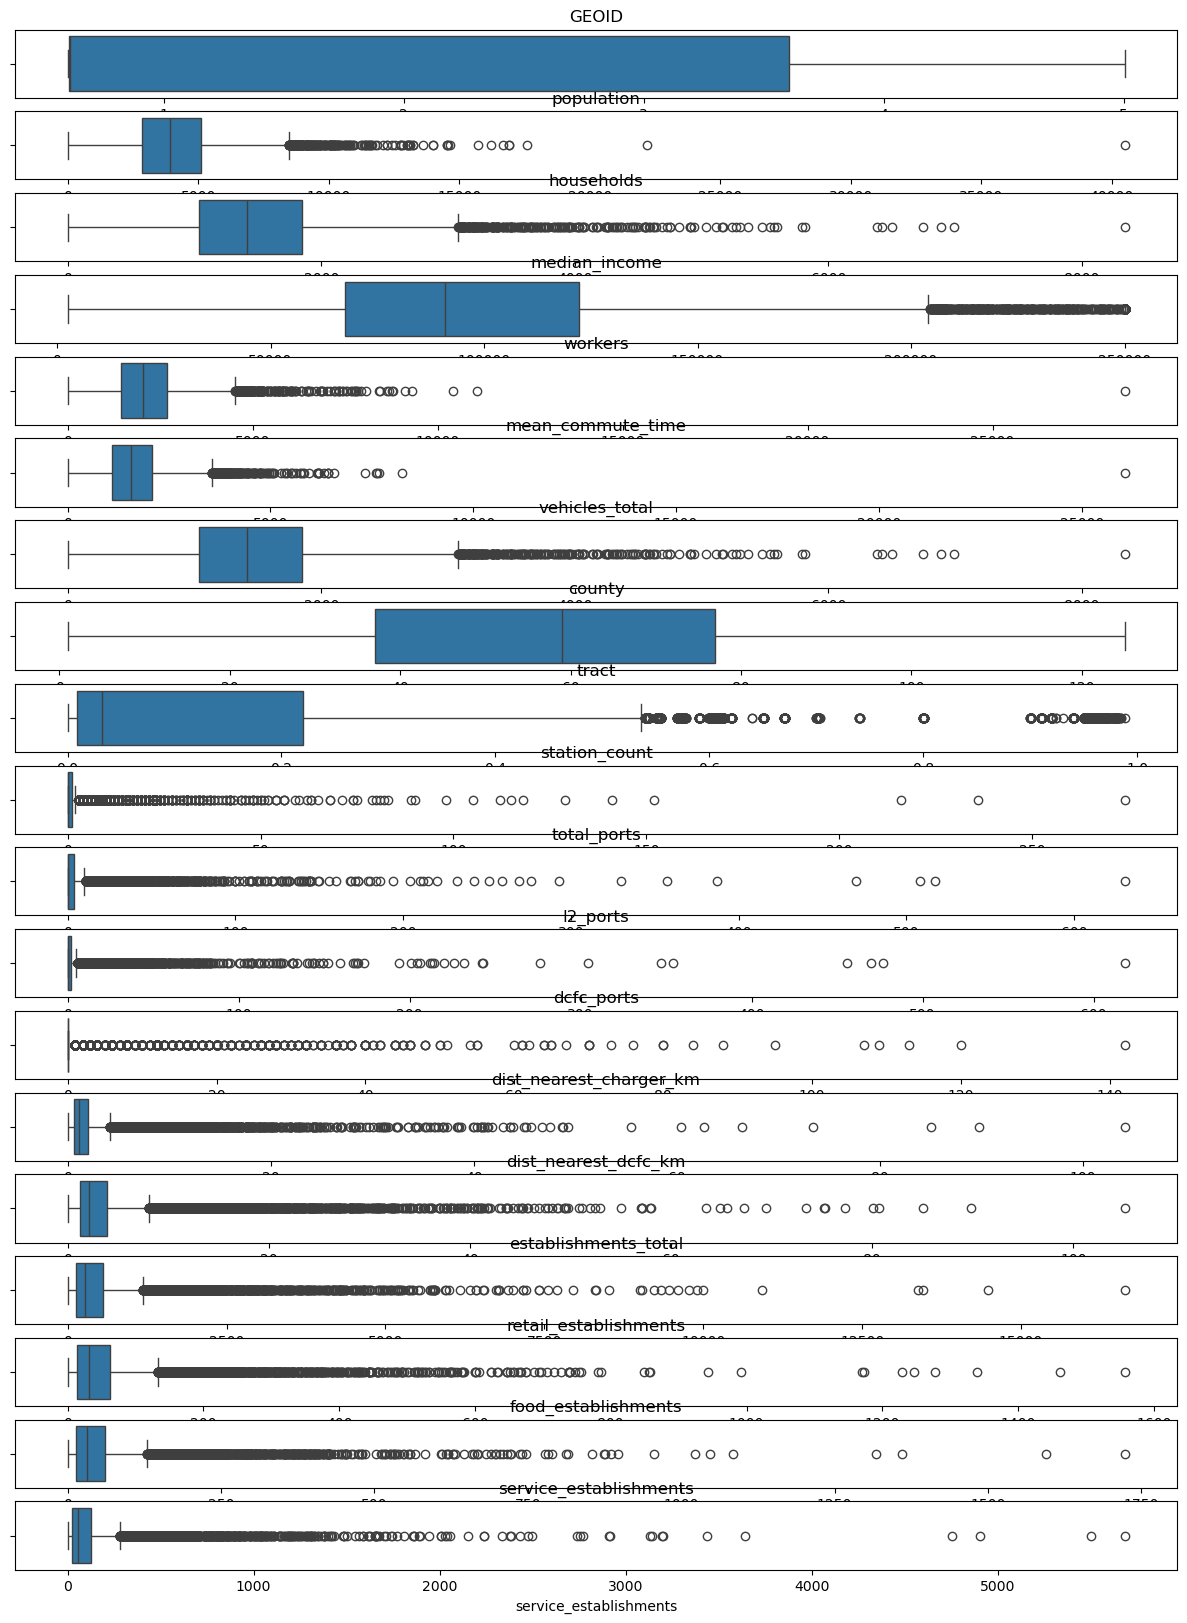

In [ ]:
plt.figure(figsize=(15, 20))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


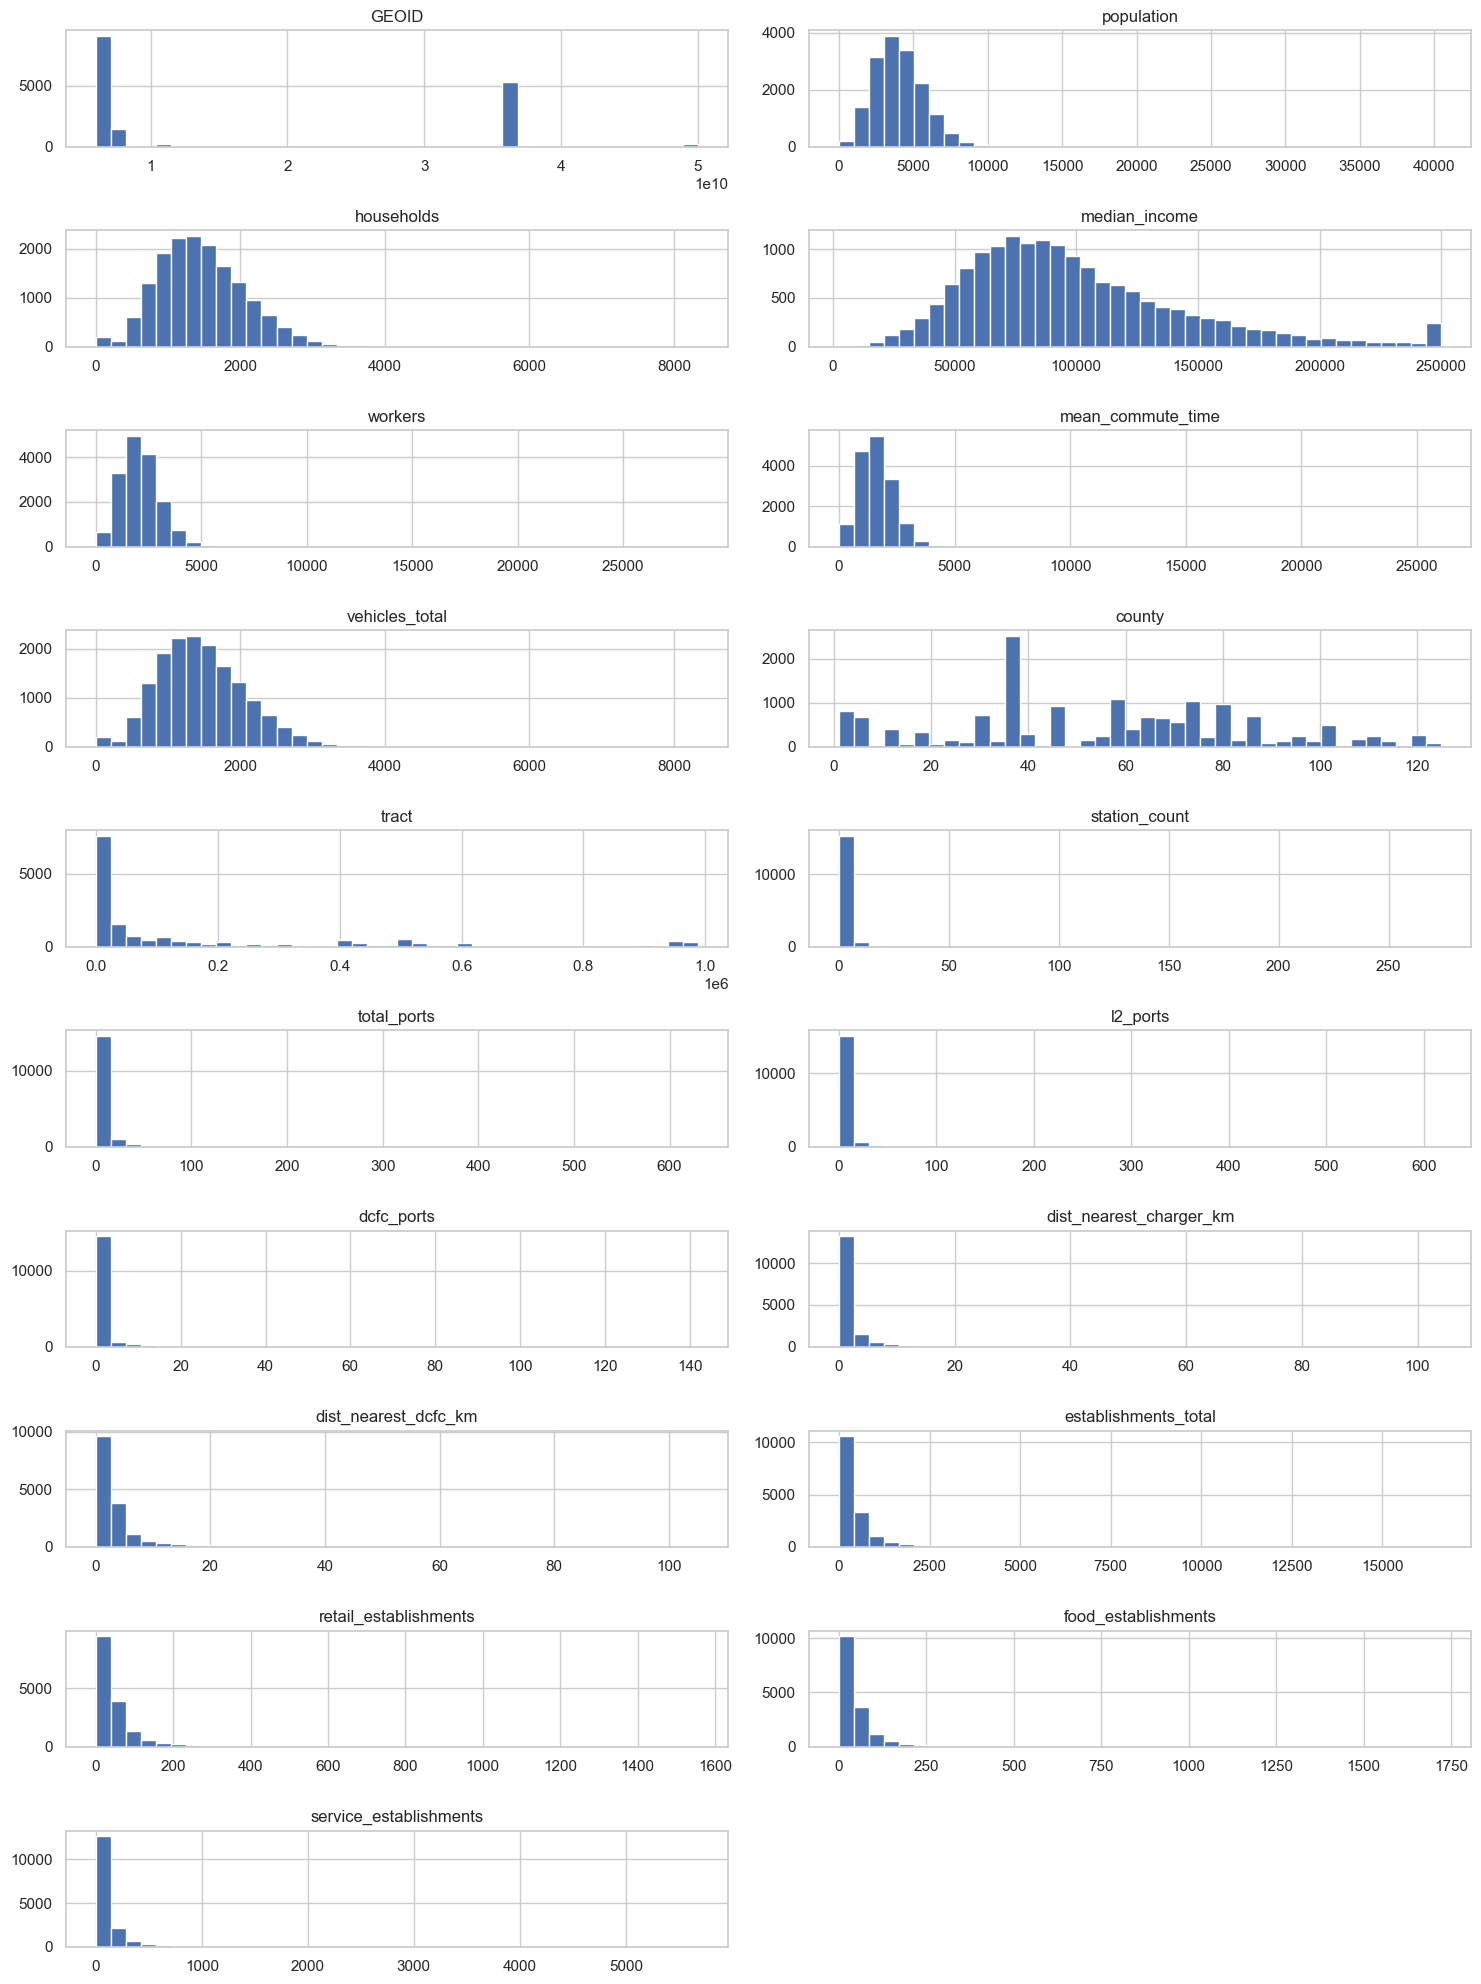

In [9]:
df[numeric_cols].hist(
    bins=40,
    figsize=(15, 20),
    layout=(len(numeric_cols)//2 + 1, 2)
)

plt.tight_layout()
plt.show()


In [13]:
outlier_summary = []

for col in numeric_cols:
    summary = {
        "variable": col,
        "min": df[col].min(),
        "median": df[col].median(),
        "p99": df[col].quantile(0.99),
        "p995": df[col].quantile(0.995),
        "max": df[col].max()
    }
    outlier_summary.append(summary)

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("p995", ascending=False)


,variable,min,median,p99,p995,max
0,GEOID,6.001400e+09,6.085511e+09,5.000596e+10,5.001995e+10,5.002797e+10
8,tract,1.000000e+02,3.230000e+04,9.705009e+05,9.775851e+05,9.883000e+05
3,median_income,2.499000e+03,9.080150e+04,2.500010e+05,2.500010e+05,2.500010e+05
1,population,2.000000e+00,3.921000e+03,8.843600e+03,1.005938e+04,4.048100e+04
4,workers,0.000000e+00,2.026000e+03,4.818950e+03,5.568975e+03,2.856600e+04
15,establishments_total,3.694576e-12,2.787034e+02,3.696000e+03,4.740365e+03,1.662755e+04
5,mean_commute_time,0.000000e+00,1.567000e+03,3.742950e+03,4.200625e+03,2.605600e+04
2,households,0.000000e+00,1.411000e+03,3.343950e+03,3.920775e+03,8.336000e+03
6,vehicles_total,0.000000e+00,1.411000e+03,3.343950e+03,3.920775e+03,8.336000e+03
18,service_establishments,0.000000e+00,5.772752e+01,9.457275e+02,1.288388e+03,5.682882e+03


In [14]:
for col in numeric_cols:
    threshold = df[col].quantile(0.995)
    ratio = (df[col] > threshold).mean()
    print(f"{col}: {round(ratio*100, 3)}% above 99.5 percentile")


GEOID: 0.506% above 99.5 percentile
population: 0.506% above 99.5 percentile
households: 0.506% above 99.5 percentile
median_income: 0.0% above 99.5 percentile
workers: 0.506% above 99.5 percentile
mean_commute_time: 0.506% above 99.5 percentile
vehicles_total: 0.506% above 99.5 percentile
county: 0.012% above 99.5 percentile
tract: 0.506% above 99.5 percentile
station_count: 0.506% above 99.5 percentile
total_ports: 0.506% above 99.5 percentile
l2_ports: 0.5% above 99.5 percentile
dcfc_ports: 0.494% above 99.5 percentile
dist_nearest_charger_km: 0.506% above 99.5 percentile
dist_nearest_dcfc_km: 0.506% above 99.5 percentile
establishments_total: 0.506% above 99.5 percentile
retail_establishments: 0.506% above 99.5 percentile
food_establishments: 0.506% above 99.5 percentile
service_establishments: 0.506% above 99.5 percentile


## Log Transformation

In [10]:
skewed_cols = [
    "population",
    "households",
    "workers",
    "vehicles_total",
    "total_ports",
    "l2_ports",
    "dcfc_ports",
    "station_count",
    "establishments_total",
    "retail_establishments",
    "food_establishments",
    "service_establishments",
    "dist_nearest_charger_km",
    "dist_nearest_dcfc_km"
]

for col in skewed_cols:
    df[f"log_{col}"] = np.log1p(df[col])

<Axes: >

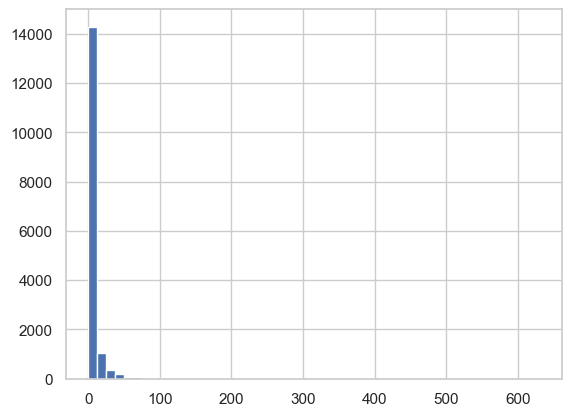

In [11]:
df["total_ports"].hist(bins=50)


<Axes: >

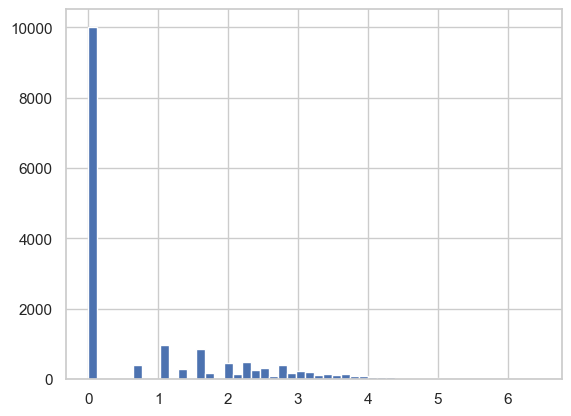

In [12]:
df["log_total_ports"].hist(bins=50)


## Feature Engineering

Per-Capita Supply Metrics

In [13]:
df["ports_per_1000_pop"] = (
    df["total_ports"] / df["population"] * 1000
)

df["stations_per_1000_pop"] = (
    df["station_count"] / df["population"] * 1000
)


Commercial Intensity Metrics

In [14]:
df["establishments_per_1000_pop"] = (
    df["establishments_total"] / df["population"] * 1000
)

df["retail_per_1000_pop"] = (
    df["retail_establishments"] / df["population"] * 1000
)

df["food_per_1000_pop"] = (
    df["food_establishments"] / df["population"] * 1000
)

df["service_per_1000_pop"] = (
    df["service_establishments"] / df["population"] * 1000
)


Accessibility Pressure Indicator

In [15]:
df["infrastructure_pressure"] = (
    df["dist_nearest_charger_km"] / (df["total_ports"] + 1)
)


Commercial vs Residential Structure

In [16]:
df["pop_to_business_ratio"] = (
    df["population"] / (df["establishments_total"] + 1)
)


DC Fast Charging Share

In [17]:
df["dcfc_share"] = (
    df["dcfc_ports"] / (df["total_ports"] + 1)
)


Demand Density Index

In [18]:
df["demand_index"] = (
    df["log_population"] +
    df["log_establishments_total"] +
    df["log_vehicles_total"]
)


## Checking data

In [19]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [20]:
print("Inf values:", np.isinf(df[numeric_cols]).sum().sum())
print("NaN values:", df[numeric_cols].isna().sum().sum())

Inf values: 0
NaN values: 0


<Axes: ylabel='Frequency'>

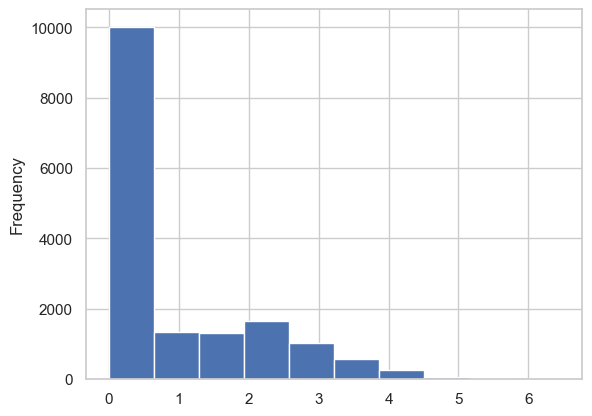

In [21]:
df['log_total_ports'].plot.hist()

In [30]:
df.to_csv(
    "data_processed/final_model_ready_full.csv",
    index=False
)

# EDA

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
print("\nSummary Statistics:\n", df.describe())


Shape: (16206, 45)

Data Types:
 GEOID                            int64
population                     float64
households                     float64
median_income                  float64
workers                        float64
mean_commute_time              float64
vehicles_total                 float64
state                              str
county                         float64
tract                          float64
state_code                         str
station_count                    int64
total_ports                      int64
l2_ports                         int64
dcfc_ports                       int64
dist_nearest_charger_km        float64
dist_nearest_dcfc_km           float64
establishments_total           float64
retail_establishments          float64
food_establishments            float64
service_establishments         float64
log_population                 float64
log_households                 float64
log_workers                    float64
log_vehicles_total             

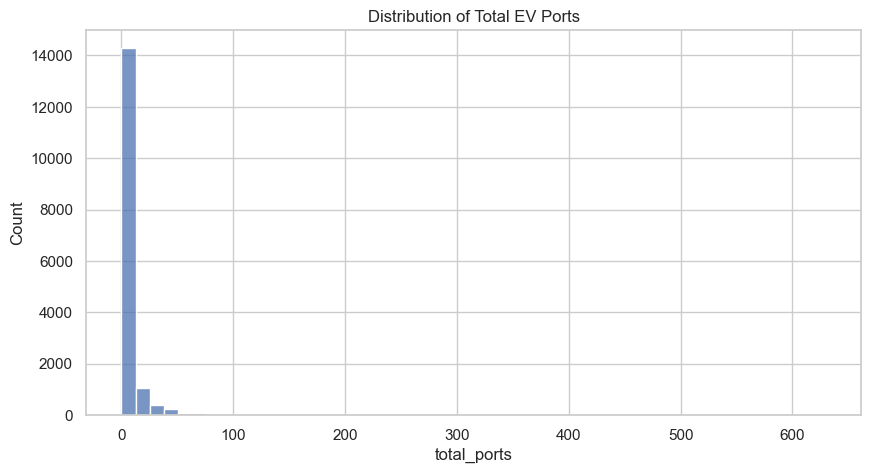

Zero charger tracts (%): 0.6181044057756386


In [23]:
plt.figure(figsize=(10,5))
sns.histplot(df["total_ports"], bins=50)
plt.title("Distribution of Total EV Ports")
plt.show()

print("Zero charger tracts (%):",
      (df["total_ports"] == 0).mean())


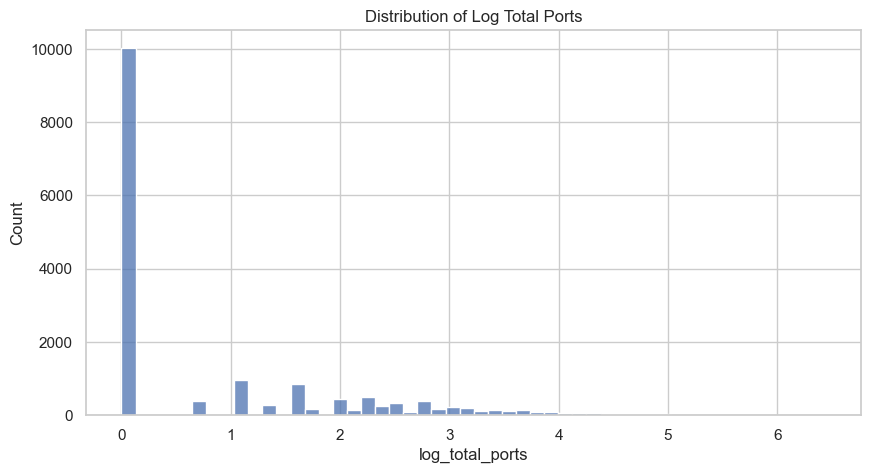

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df["log_total_ports"], bins=50)
plt.title("Distribution of Log Total Ports")
plt.show()


### Feature Distribution (All Numerical Variables)

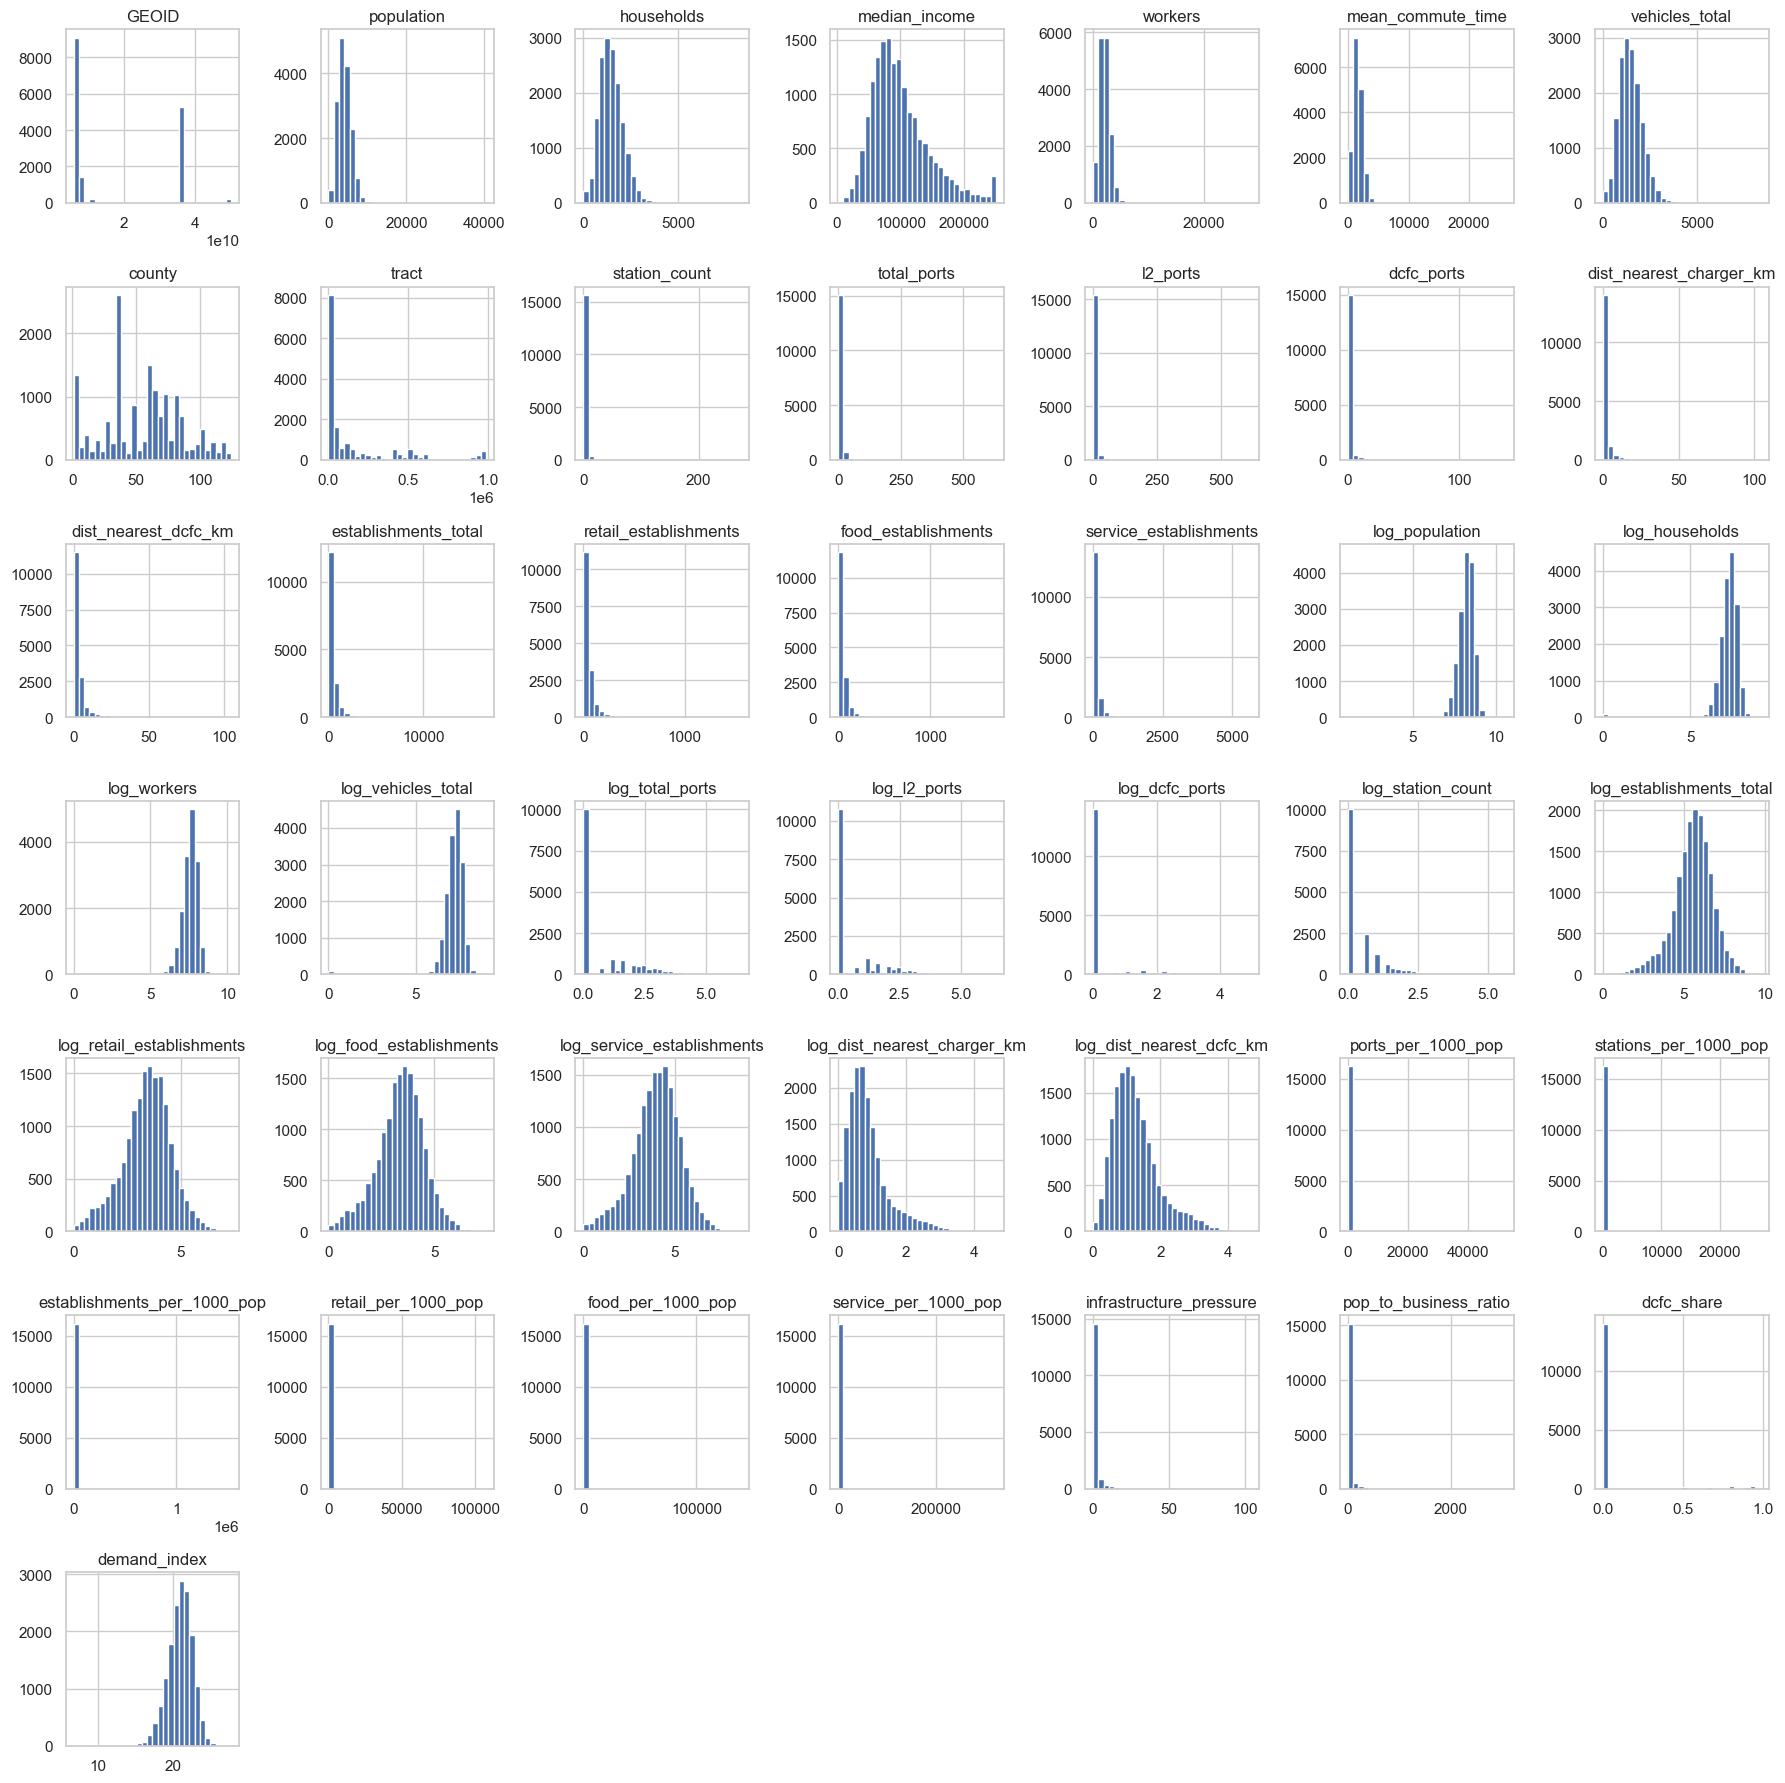

In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(18, 18),
    bins=30
)
plt.tight_layout()
plt.show()


In [26]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness:\n", skewness)


Skewness:
 stations_per_1000_pop          121.056423
ports_per_1000_pop             120.340078
establishments_per_1000_pop     78.600360
service_per_1000_pop            66.474832
food_per_1000_pop               62.740459
retail_per_1000_pop             59.796957
station_count                   17.569902
l2_ports                        14.595263
total_ports                     12.320665
pop_to_business_ratio           10.310483
dcfc_ports                       8.444191
service_establishments           8.422011
infrastructure_pressure          8.197521
dist_nearest_charger_km          7.173304
food_establishments              5.997927
establishments_total             5.981724
retail_establishments            5.689504
dist_nearest_dcfc_km             5.087411
dcfc_share                       2.908445
log_dcfc_ports                   2.833534
mean_commute_time                2.726576
workers                          2.129053
tract                            1.801810
log_station_count      

## Correlation

In [27]:
corr_target = df.corr(numeric_only=True)["log_total_ports"] \
                .sort_values(ascending=False)

print(corr_target)


log_total_ports                1.000000
log_station_count              0.928972
log_l2_ports                   0.908127
total_ports                    0.668740
log_dcfc_ports                 0.610511
l2_ports                       0.580727
station_count                  0.543147
dcfc_ports                     0.493367
dcfc_share                     0.472242
service_establishments         0.236937
establishments_total           0.236895
food_establishments            0.227402
log_food_establishments        0.224593
log_service_establishments     0.223556
log_establishments_total       0.212342
demand_index                   0.202550
vehicles_total                 0.195815
households                     0.195815
retail_establishments          0.191653
log_retail_establishments      0.168471
workers                        0.135453
log_households                 0.111205
log_vehicles_total             0.111205
log_workers                    0.097175
mean_commute_time              0.094216


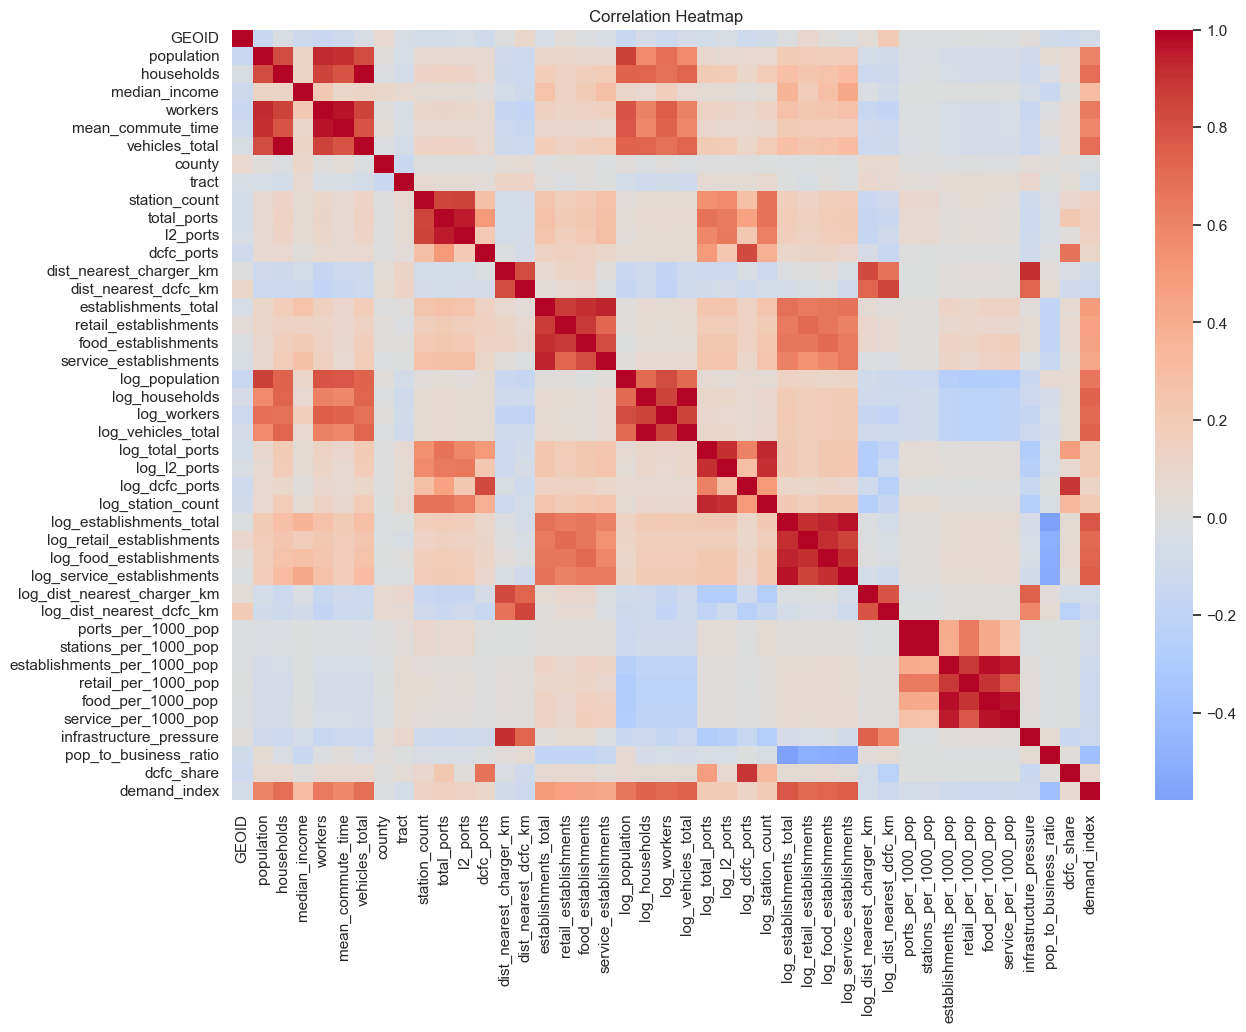

In [28]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()


## Zero vs Non-Zero Analysis

In [29]:
df["has_charger"] = (df["total_ports"] > 0).astype(int)

comparison = df.groupby("has_charger").mean(numeric_only=True)
print(comparison)


                    GEOID   population   households  median_income  \
has_charger                                                          
0            1.743926e+10  3988.756714  1393.210842   98191.425626   
1            1.526928e+10  4234.066085  1623.034739  102016.333899   

                 workers  mean_commute_time  vehicles_total     county  \
has_charger                                                              
0            2032.316462        1593.354897     1393.210842  55.556254   
1            2255.355954        1714.569074     1623.034739  55.487801   

                     tract  station_count  ...  ports_per_1000_pop  \
has_charger                                ...                       
0            155301.861535       0.000499  ...            0.000000   
1            186459.840362       4.380675  ...           15.540228   

             stations_per_1000_pop  establishments_per_1000_pop  \
has_charger                                                       
0      

# Population vs Chargers

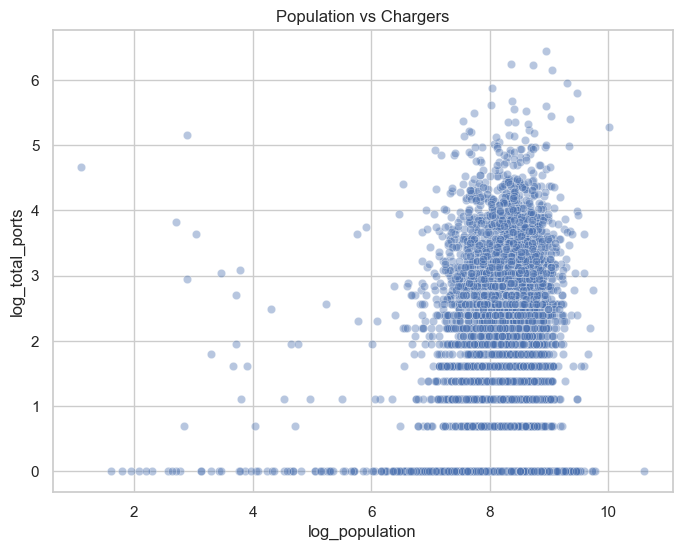

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="log_population",
    y="log_total_ports",
    data=df,
    alpha=0.4
)
plt.title("Population vs Chargers")
plt.show()


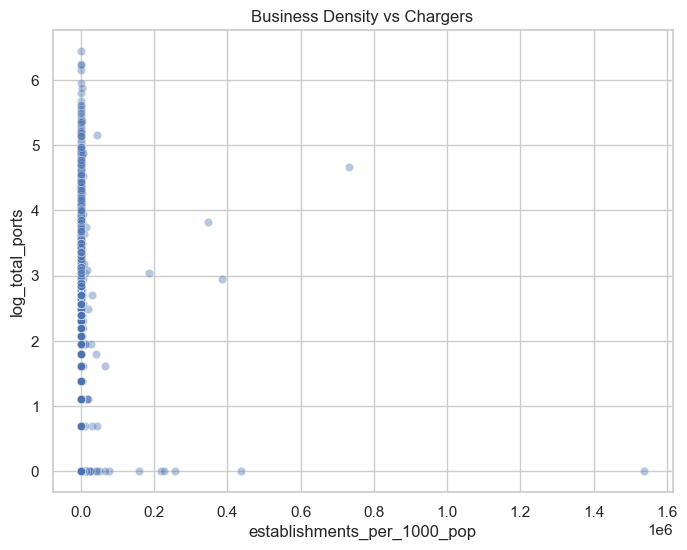

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="establishments_per_1000_pop",
    y="log_total_ports",
    data=df,
    alpha=0.4
)
plt.title("Business Density vs Chargers")
plt.show()
